# NLP Project 3: Movie Review Classification

A movie streaming platform receives large numbers of audience reviews for newly released movies and web series. These reviews contain viewer opinions about acting, storyline, music, direction, and overall entertainment value. The platform wants to understand audience reactions and classify reviews into positive, negative, or neutral categories to measure movie popularity and improve content recommendations. Manual review analysis is not practical due to the huge amount of text data generated daily.


## Tasks
1. Collect movie review data.
2. Preprocess review text.
3. Build a sentiment classification model.
4. Analyze audience opinions.
5. Visualize sentiment results.

In [1]:
# Load required libraries
import re
import string
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# NLTK imports and corpus download if needed
import nltk
from nltk.corpus import movie_reviews, stopwords
from nltk.stem import WordNetLemmatizer

for resource in ['movie_reviews', 'punkt', 'wordnet', 'omw-1.4', 'stopwords']:
    try:
        nltk.data.find(f'corpora/{resource}')
    except LookupError:
        nltk.download(resource)

# Build dataset from NLTK movie_reviews corpus
documents = [(movie_reviews.raw(fileid), category)
             for category in movie_reviews.categories()
             for fileid in movie_reviews.fileids(category)]
df = pd.DataFrame(documents, columns=['review', 'label'])
df['label'] = df['label'].map({'pos': 'positive', 'neg': 'negative'})

print('Dataset shape:', df.shape)
print(df['label'].value_counts())


[nltk_data] Downloading package movie_reviews to /root/nltk_data...
[nltk_data]   Unzipping corpora/movie_reviews.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Dataset shape: (2000, 2)
label
negative    1000
positive    1000
Name: count, dtype: int64


Sample review:
plot : two teen couples go to a church party , drink and then drive . 
they get into an accident . 
one of the guys dies , but his girlfriend continues to see him in her life , and has nightmares . 
what's the deal ? 
watch the movie and " sorta " find out . . . 
critique : a mind-fuck movie for the teen generation that touches on a very cool idea , but presents it in a very bad package . 
which is what makes this review an even harder one to write , since i generally applaud films which attempt to break the mold , mess with your head and such ( lost highway & memento ) , but there are good and bad ways of making all types of films , and these folks just didn't snag this one correctly . 
they seem to have taken this pretty neat concept , but executed it terribly . 
so what are the problems


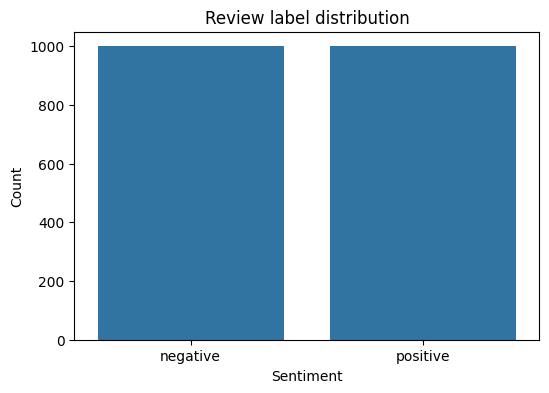

In [2]:
# Explore the dataset
print('Sample review:')
print(df['review'].iloc[0][:800])

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='label')
plt.title('Review label distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()


In [3]:
# Preprocessing pipeline
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words and len(word) > 1]
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    return ' '.join(tokens)

df['clean_review'] = df['review'].apply(clean_text)
print('Example cleaned review:')
print(df['clean_review'].iloc[0][:800])


Example cleaned review:
plot two teen couple go church party drink drive get accident one guy dy girlfriend continues see life nightmare deal watch movie sorta find critique mind fuck movie teen generation touch cool idea present bad package make review even harder one write since generally applaud film attempt break mold mess head lost highway memento good bad way making type film folk snag one correctly seem taken pretty neat concept executed terribly problem movie well main problem simply jumbled start normal downshift fantasy world audience member idea going dream character coming back dead others look like dead strange apparition disappearance looooot chase scene ton weird thing happen simply explained personally mind trying unravel film every give clue get kind fed film biggest problem obviously got big sec


In [4]:
# Feature extraction and train/test split
vectorizer = TfidfVectorizer(max_df=0.9, min_df=5, ngram_range=(1, 2))
X = vectorizer.fit_transform(df['clean_review'])
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print('Training samples:', X_train.shape[0])
print('Test samples:', X_test.shape[0])


Training samples: 1600
Test samples: 400


Accuracy: 0.835

Classification report:
              precision    recall  f1-score   support

    negative       0.85      0.81      0.83       200
    positive       0.82      0.86      0.84       200

    accuracy                           0.83       400
   macro avg       0.84      0.83      0.83       400
weighted avg       0.84      0.83      0.83       400



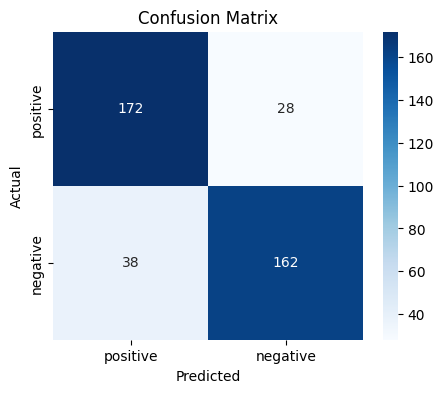

In [5]:
# Train sentiment classification model
model = LogisticRegression(max_iter=300)
model.fit(X_train, y_train)

predictions = model.predict(X_test)
print('Accuracy:', accuracy_score(y_test, predictions))
print()
print('Classification report:')
print(classification_report(y_test, predictions))

conf_matrix = confusion_matrix(y_test, predictions, labels=['positive', 'negative'])
plt.figure(figsize=(5, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['positive', 'negative'], yticklabels=['positive', 'negative'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


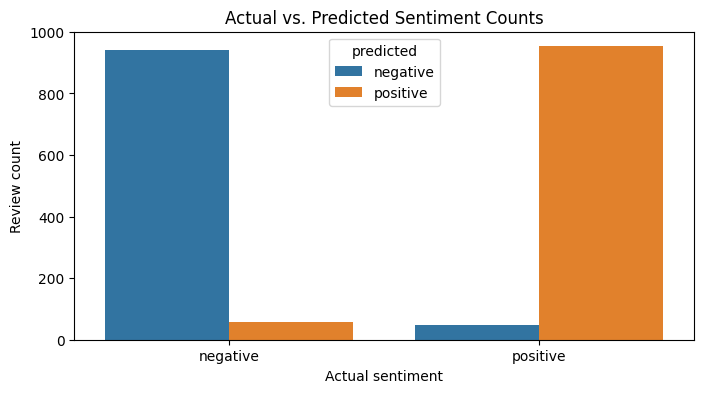

In [6]:
# Visualize sentiment results
df['predicted'] = model.predict(X)
summary = df.groupby(['label', 'predicted']).size().reset_index(name='count')

plt.figure(figsize=(8, 4))
sns.barplot(data=summary, x='label', y='count', hue='predicted')
plt.title('Actual vs. Predicted Sentiment Counts')
plt.xlabel('Actual sentiment')
plt.ylabel('Review count')
plt.show()
